In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
    )

# Optional: XGBoost (if not installed, pipeline still runs with 3 models)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost is not installed. Install with: pip install xgboost")

# Load datasets (v2) from data folder
train = pd.read_csv('data/ml_dataset_v2_train.csv')
dev   = pd.read_csv('data/ml_dataset_v2_dev.csv')

print('Datasets loaded successfully.')
print(f'Train shape: {train.shape}')
print(f'Dev shape:   {dev.shape}')
print('\nTrain label distribution:')
print(train['label'].value_counts(normalize=True).rename('ratio'))

Datasets loaded successfully.
Train shape: (250, 8)
Dev shape:   (100, 8)

Train label distribution:
label
0    0.6
1    0.4
Name: ratio, dtype: float64


In [2]:
# EDA 1: data quality + summary statistics + target distribution + frequency table
print('--- Train Info ---')
train.info()

print('\n--- Descriptive Statistics ---')
display(train.describe(include='all').T)

print('\n--- Missing Values Check ---')
display(train.isnull().sum().to_frame('missing_count'))

print('\n--- Target Distribution (Count / Ratio) ---')
target_count = train['label'].value_counts().sort_index()
target_ratio = train['label'].value_counts(normalize=True).sort_index()
display(pd.DataFrame({'count': target_count, 'ratio': target_ratio}))

# Frequency table for discrete/categorical-like variable
print('\n--- Frequency Table: part_time_job_hours ---')
freq_part_time = train['part_time_job_hours'].value_counts().sort_index()
display(freq_part_time.to_frame('count'))

# Create income groups for categorical EDA
income_bins = [0, 800, 1500, np.inf]
income_labels = ['low', 'medium', 'high']
train['income_group'] = pd.cut(train['household_income'], bins=income_bins, labels=income_labels, include_lowest=True)
print('\n--- Frequency Table: income_group ---')
display(train['income_group'].value_counts(dropna=False).to_frame('count'))

--- Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    250 non-null    int64  
 1   gpa                   250 non-null    float64
 2   attendance_rate       250 non-null    float64
 3   study_hours_per_week  250 non-null    int64  
 4   exam_score            250 non-null    int64  
 5   household_income      250 non-null    int64  
 6   part_time_job_hours   250 non-null    int64  
 7   label                 250 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 15.8 KB

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
id,250.0,125.50000,72.312977,1.0,63.250,125.500,187.75,250.00
gpa,250.0,3.00544,0.597578,2.0,2.445,3.015,3.50,3.99
attendance_rate,250.0,0.80392,0.116508,0.6,0.710,0.805,0.91,1.00
study_hours_per_week,250.0,21.98400,9.647177,5.0,14.000,22.000,30.00,39.00
exam_score,250.0,71.56800,16.087030,45.0,57.000,71.500,85.00,99.00
household_income,250.0,1394.74400,656.450372,205.0,873.000,1436.500,1957.25,2497.00
part_time_job_hours,250.0,12.50000,7.433372,0.0,6.000,13.000,19.00,24.00
label,250.0,0.40000,0.490881,0.0,0.000,0.000,1.00,1.00



--- Missing Values Check ---


,missing_count
id,0
gpa,0
attendance_rate,0
study_hours_per_week,0
exam_score,0
household_income,0
part_time_job_hours,0
label,0



--- Target Distribution (Count / Ratio) ---


,count,ratio
label,,
0,150,0.6
1,100,0.4



--- Frequency Table: part_time_job_hours ---


,count
part_time_job_hours,
0,7
1,8
2,13
3,13
4,12
5,9
6,6
7,9
8,9



--- Frequency Table: income_group ---


,count
income_group,
high,116
medium,78
low,56


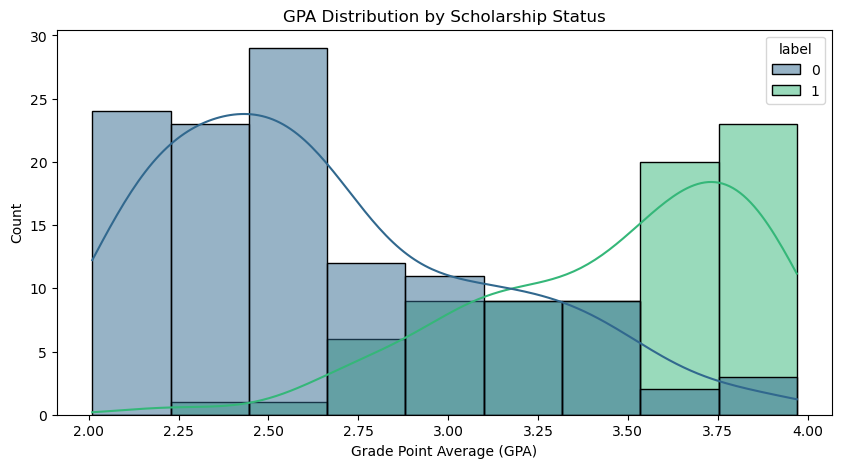

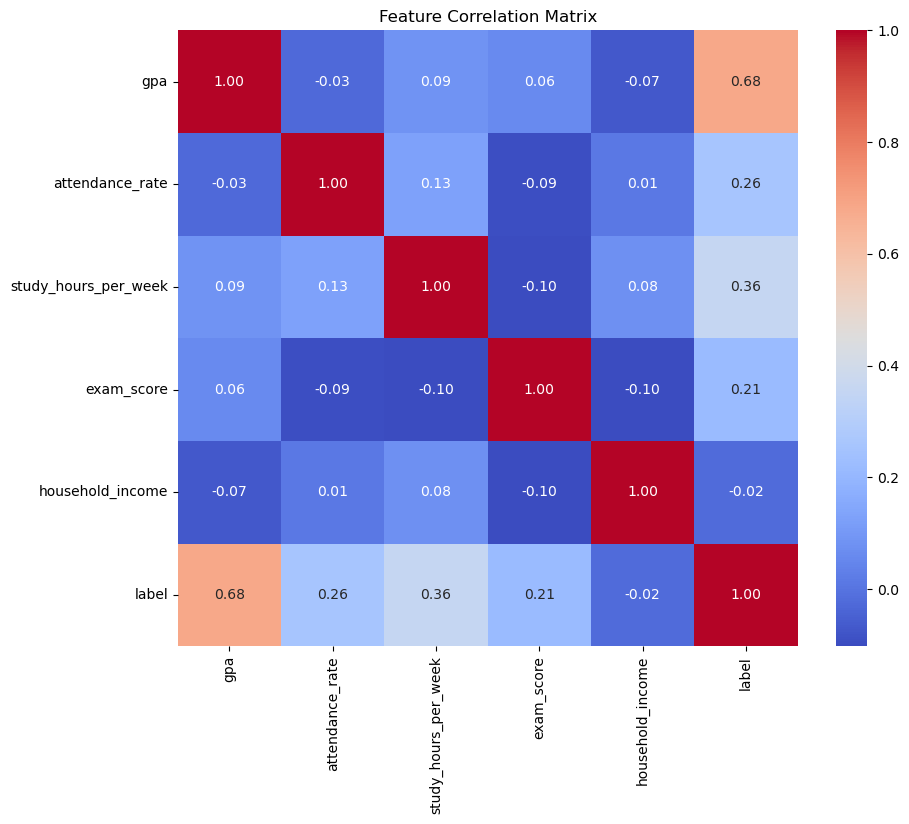

In [ ]:
# EDA 2: target distribution + key numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=train, x='label', palette='viridis', ax=axes[0])
axes[0].set_title('Target Distribution (label)')
axes[0].set_xlabel('Scholarship label')

sns.histplot(data=train, x='gpa', hue='label', kde=True, palette='viridis', ax=axes[1])
axes[1].set_title('GPA Distribution by Label')

sns.histplot(data=train, x='exam_score', hue='label', kde=True, palette='magma', ax=axes[2])
axes[2].set_title('Exam Score Distribution by Label')

plt.tight_layout()
plt.show()

# Quick note for preprocessing decisions
print('EDA note: label seems moderately imbalanced; use F1/PR-AUC in addition to accuracy.')

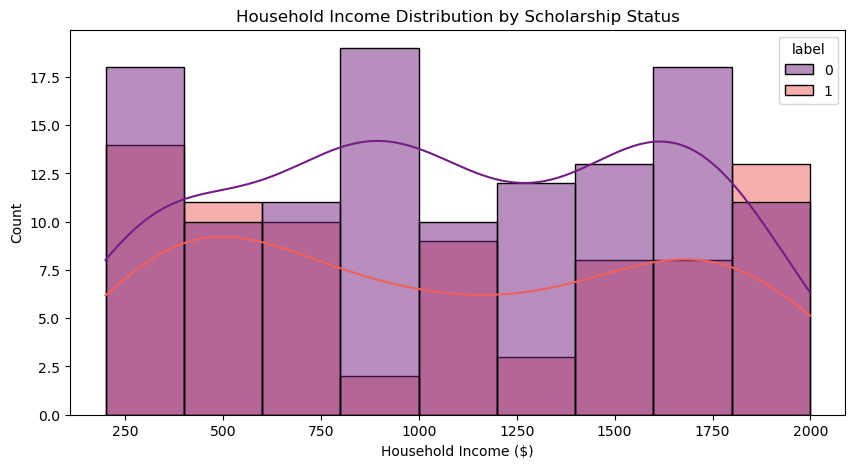

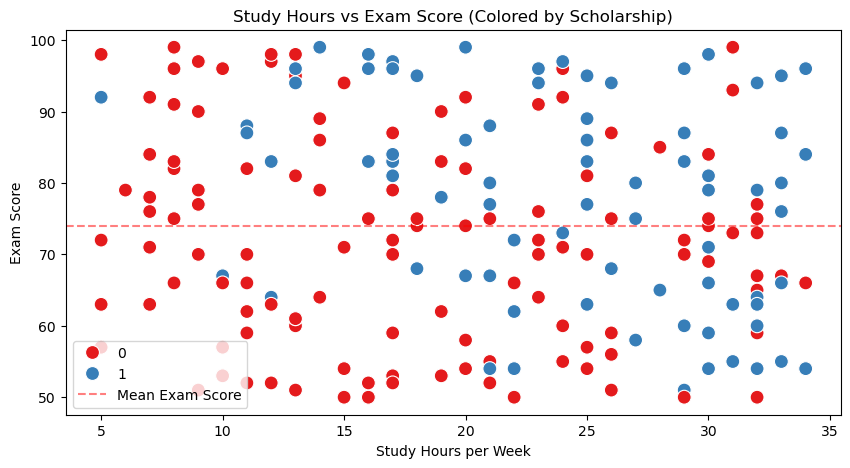

In [ ]:
# EDA 3: categorical/discrete charts + correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart for categorical-like income_group vs label
income_label_tab = pd.crosstab(train['income_group'], train['label'], normalize='index')
income_label_tab.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Label Ratio by Income Group')
axes[0].set_xlabel('Income group')
axes[0].set_ylabel('Ratio')
axes[0].legend(title='label')

# Bar chart for discrete part_time_job_hours
part_time_mean = train.groupby('part_time_job_hours')['label'].mean().reset_index()
sns.barplot(data=part_time_mean, x='part_time_job_hours', y='label', color='#4C72B0', ax=axes[1])
axes[1].set_title('Scholarship Rate by Part-time Job Hours')
axes[1].set_ylabel('Mean label (scholarship rate)')
axes[1].set_xlabel('Part-time job hours')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(train.drop(columns=['id']).corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

print('EDA-preprocessing link: scaling is required for LR/SVM due to different feature magnitudes.')

### Justification for Preprocessing Decisions
- **Feature Engineering (interaction terms):** Keep `gpa_attendance` and `study_exam` because EDA suggests scholarship depends on combined academic behavior signals, not only single features.
- **Feature Scaling:** `StandardScaler` is kept because LR/SVM are scale-sensitive and features have very different ranges (e.g., `household_income` vs `attendance_rate`).
- **Metric Strategy:** Besides Accuracy/F1, add **ROC-AUC** and **PR-AUC** to evaluate ranking quality and positive-class performance under moderate imbalance.

In [2]:
# Feature Engineering + train/dev split preparation
def add_features(df):
    df = df.copy()
    df['gpa_attendance'] = df['gpa'] * df['attendance_rate']
    df['study_exam'] = df['study_hours_per_week'] * df['exam_score']
    return df

train_fe = add_features(train)
dev_fe   = add_features(dev)

# Prepare Features (X) and Target (y)
X_train = train_fe.drop(['id', 'label', 'income_group'], axis=1, errors='ignore')
y_train = train_fe['label']
X_dev   = dev_fe.drop(['id', 'label', 'income_group'], axis=1, errors='ignore')
y_dev   = dev_fe['label']

feature_names = X_train.columns.tolist()

# Standard scaling for scale-sensitive models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled   = scaler.transform(X_dev)

print('Feature engineering and scaling completed.')
print('Final feature columns:', feature_names)

Feature engineering and scaling completed.
Final feature columns: ['gpa', 'attendance_rate', 'study_hours_per_week', 'exam_score', 'household_income', 'part_time_job_hours', 'gpa_attendance', 'study_exam']


In [3]:
# Train 3+ models with GridSearchCV: Logistic Regression, Random Forest, SVM, and optional XGBoost
trained_models = {}
cv_summary = []

# 1) Logistic Regression
lr = LogisticRegression(max_iter=3000, random_state=42, solver='liblinear')
grid_lr = GridSearchCV(
    lr,
    {'C': [0.1, 1, 10, 50]},
    cv=5,
    scoring='f1',
    n_jobs=-1
    )
grid_lr.fit(X_train_scaled, y_train)
trained_models['Logistic Regression'] = grid_lr.best_estimator_
cv_summary.append({'model': 'Logistic Regression', 'best_params': grid_lr.best_params_, 'cv_best_f1': grid_lr.best_score_})

# 2) Random Forest
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(
    rf,
    {'n_estimators': [200, 300], 'max_depth': [8, 12, None]},
    cv=5,
    scoring='f1',
    n_jobs=-1
    )
grid_rf.fit(X_train, y_train)
trained_models['Random Forest'] = grid_rf.best_estimator_
cv_summary.append({'model': 'Random Forest', 'best_params': grid_rf.best_params_, 'cv_best_f1': grid_rf.best_score_})

# 3) SVM
svm = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(
    svm,
    {'C': [0.5, 1, 5], 'kernel': ['rbf', 'linear'], 'gamma': ['scale']},
    cv=5,
    scoring='f1',
    n_jobs=-1
    )
grid_svm.fit(X_train_scaled, y_train)
trained_models['SVM'] = grid_svm.best_estimator_
cv_summary.append({'model': 'SVM', 'best_params': grid_svm.best_params_, 'cv_best_f1': grid_svm.best_score_})

# 4) XGBoost (optional but recommended)
if HAS_XGB:
    xgb = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9
        )
    xgb.fit(X_train, y_train)
    trained_models['XGBoost'] = xgb
    cv_summary.append({'model': 'XGBoost', 'best_params': {'manual': 'preset'}, 'cv_best_f1': np.nan})

cv_results_df = pd.DataFrame(cv_summary)
display(cv_results_df)
print(f'Total trained models: {len(trained_models)}')

,model,best_params,cv_best_f1
0,Logistic Regression,{'C': 1},0.970482
1,Random Forest,"{'max_depth': 8, 'n_estimators': 200}",0.916231
2,SVM,"{'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}",0.966738
3,XGBoost,{'manual': 'preset'},NaN


Total trained models: 4


--- Model Comparison on Dev ---


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.92,1.0,0.800,0.888889,0.998333,0.997727
1,SVM,0.92,1.0,0.800,0.888889,0.995833,0.994152
2,Random Forest,0.90,1.0,0.750,0.857143,0.977083,0.969925
3,XGBoost,0.89,1.0,0.725,0.840580,0.992500,0.990470


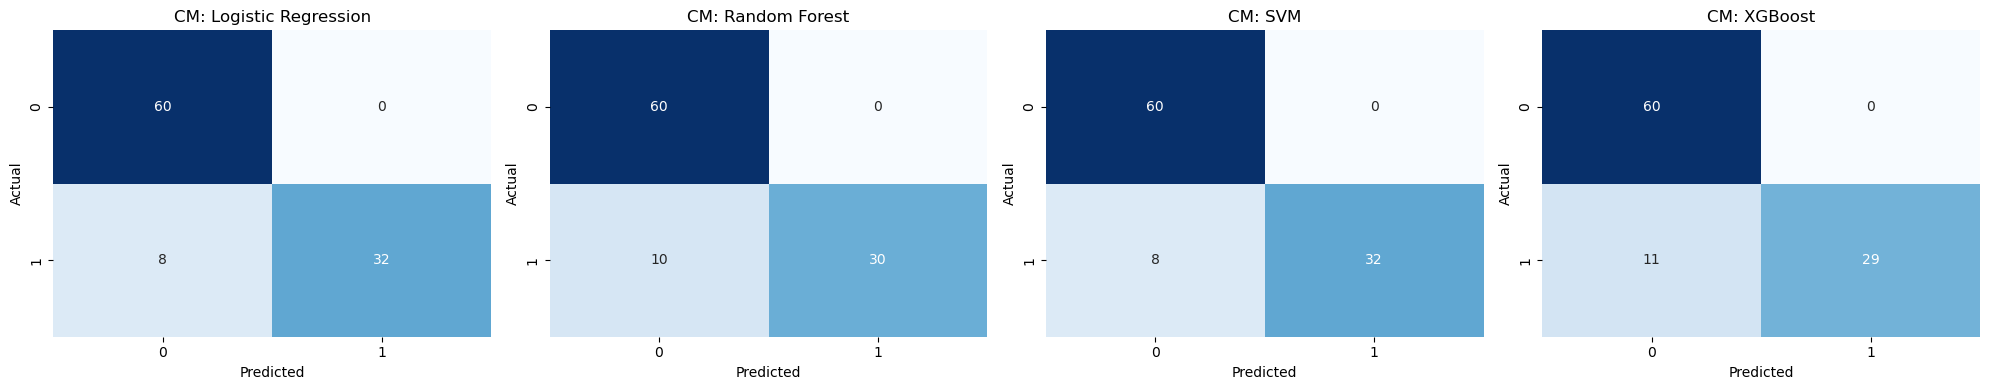

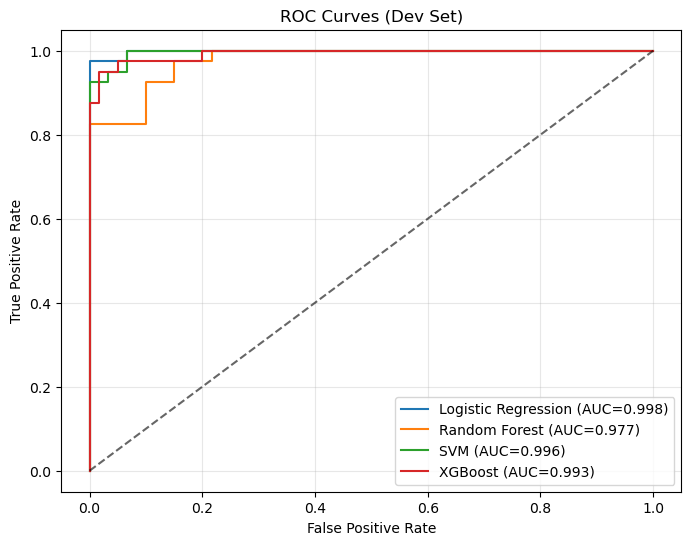

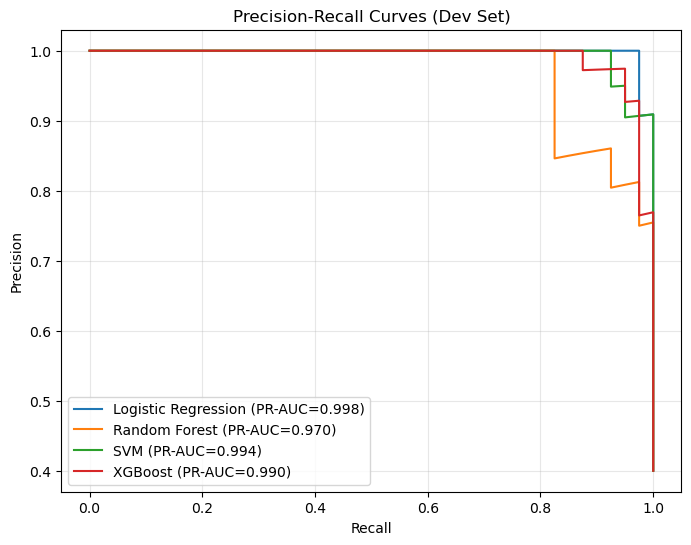

In [4]:
# Evaluate models on dev set + confusion matrix + ROC/PR curves + model comparison table
def get_scores(model, X_for_pred, y_true):
    y_pred = model.predict(X_for_pred)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_for_pred)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_for_pred)
    else:
        y_score = y_pred

    metrics_row = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    return y_pred, y_score, metrics_row

evaluation_rows = []
model_preds = {}
model_scores = {}

for model_name, model in trained_models.items():
    if model_name in ['Logistic Regression', 'SVM']:
        X_eval = X_dev_scaled
    else:
        X_eval = X_dev

    y_pred, y_score, row = get_scores(model, X_eval, y_dev)
    row['model'] = model_name
    evaluation_rows.append(row)
    model_preds[model_name] = y_pred
    model_scores[model_name] = y_score

# Comparison table
comparison_df = pd.DataFrame(evaluation_rows)[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]
comparison_df = comparison_df.sort_values(by=['f1', 'pr_auc', 'roc_auc'], ascending=False).reset_index(drop=True)
print('--- Model Comparison on Dev ---')
display(comparison_df)

# Confusion matrices
n_models = len(trained_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_dev, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'CM: {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC-AUC curves
plt.figure(figsize=(8, 6))
for model_name, y_score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_dev, y_score)
    auc_value = roc_auc_score(y_dev, y_score)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('ROC Curves (Dev Set)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# PR-AUC curves
plt.figure(figsize=(8, 6))
for model_name, y_score in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_dev, y_score)
    ap_value = average_precision_score(y_dev, y_score)
    plt.plot(recall, precision, label=f'{model_name} (PR-AUC={ap_value:.3f})')
plt.title('Precision-Recall Curves (Dev Set)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Expanded Error Analysis Strategy
Instead of analyzing only a few individual samples, we analyze **error patterns by groups** to detect systematic weaknesses:
1. Income effect: does the model fail more on high-income students?
2. Borderline GPA region: does the model struggle around the decision boundary?
3. Exam score ranges: where are false positives / false negatives concentrated?

This helps connect model behavior with policy-like scholarship rules and improve future feature engineering.

Best model on dev by F1/PR-AUC/ROC-AUC ranking: Logistic Regression

--- Error Rate by Income Group ---


,income_group,error_rate
0,low,0.129032
1,medium,0.033333
2,high,0.076923



--- Error Rate by GPA Band ---


,gpa_band,error_rate
0,low_gpa,0.090909
1,borderline_gpa,0.130435
2,high_gpa,0.030303



--- Error Rate by Exam Score Band ---


,exam_band,error_rate
0,low_exam,0.096774
1,mid_exam,0.038462
2,high_exam,0.093023


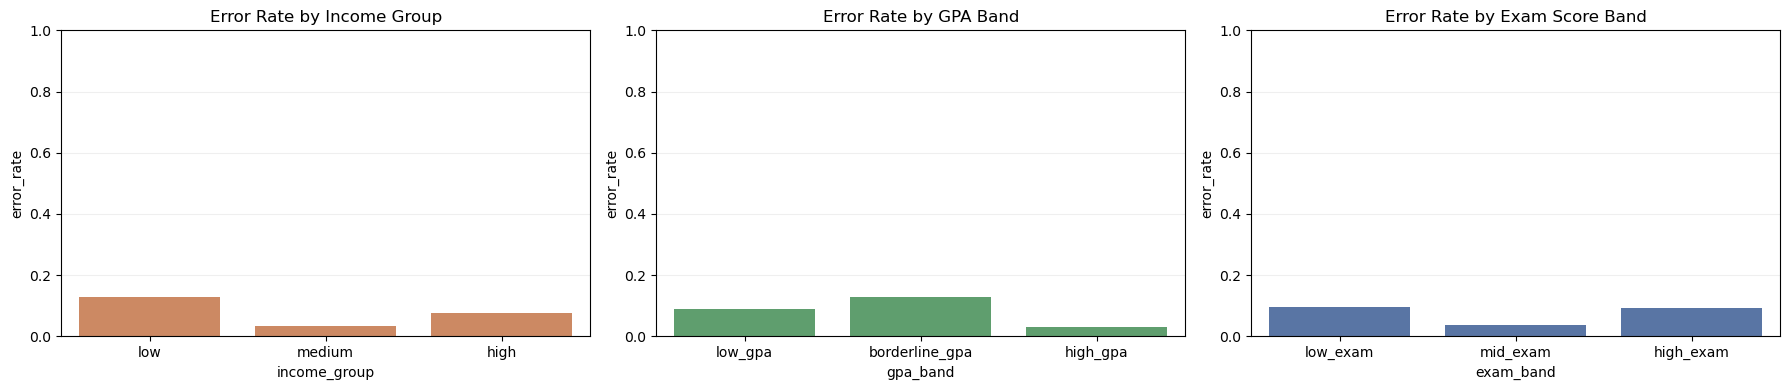


--- Model Interpretation ---
Top Logistic Regression coefficients (absolute impact):


,feature,coefficient
0,gpa,2.655678
6,gpa_attendance,2.049760
3,exam_score,1.935003
7,study_exam,1.315098
2,study_hours_per_week,1.077393
5,part_time_job_hours,-0.643140
1,attendance_rate,0.600258
4,household_income,0.007121


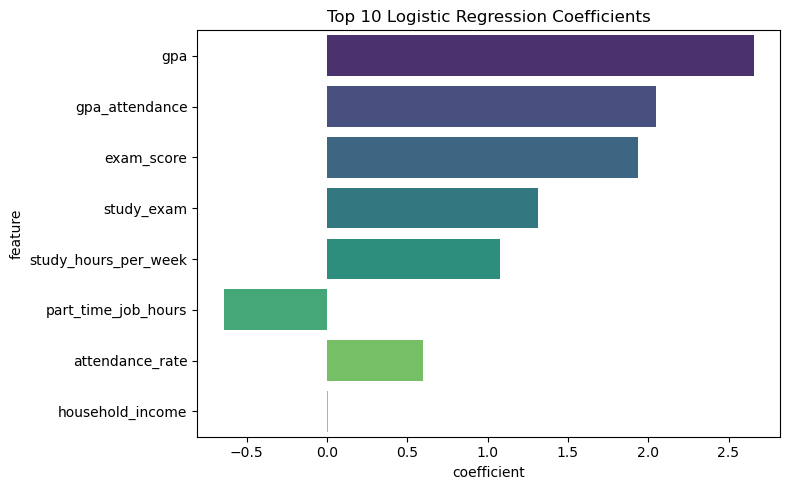

Top Random Forest feature importance:


,feature,importance
0,gpa,0.306710
6,gpa_attendance,0.242222
7,study_exam,0.139987
3,exam_score,0.101503
2,study_hours_per_week,0.081028
1,attendance_rate,0.046114
5,part_time_job_hours,0.045241
4,household_income,0.037194


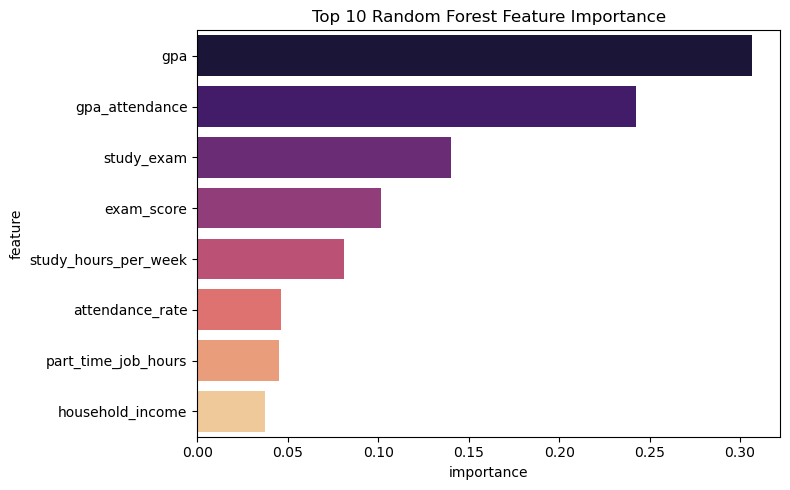

Top XGBoost feature importance:


,feature,importance
6,gpa_attendance,0.279110
0,gpa,0.271023
7,study_exam,0.177380
3,exam_score,0.110645
2,study_hours_per_week,0.053388
1,attendance_rate,0.050124
5,part_time_job_hours,0.037942
4,household_income,0.020387


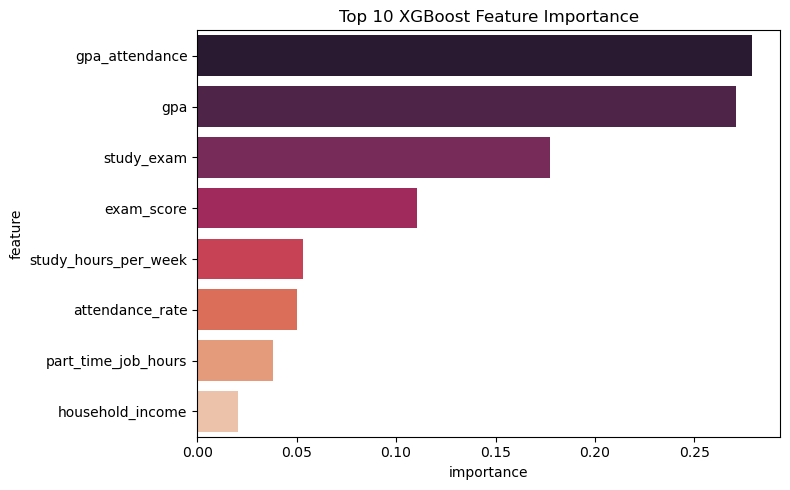


=== Final Recommendation ===
Choose the model with highest F1 while checking PR-AUC and ROC-AUC stability on dev set.
Selected model: Logistic Regression
Reason: best ranking in comparison table, plus balanced precision-recall behavior.
Use this model as final deployment candidate, and retrain on larger data in final submission pipeline.


In [5]:
# Group-based error analysis + model interpretation + final recommendation
best_model_name = comparison_df.loc[0, 'model']
best_model = trained_models[best_model_name]
print(f'Best model on dev by F1/PR-AUC/ROC-AUC ranking: {best_model_name}')

# Prepare dev frame for analysis
dev_analysis = dev_fe.copy()
if best_model_name in ['Logistic Regression', 'SVM']:
    y_pred_best = best_model.predict(X_dev_scaled)
else:
    y_pred_best = best_model.predict(X_dev)

dev_analysis['predicted'] = y_pred_best
dev_analysis['is_error'] = (dev_analysis['label'] != dev_analysis['predicted']).astype(int)

# Income group error rate
dev_analysis['income_group'] = pd.cut(dev_analysis['household_income'], bins=[0, 800, 1500, np.inf], labels=['low', 'medium', 'high'], include_lowest=True)
income_error = dev_analysis.groupby('income_group')['is_error'].mean().reset_index().rename(columns={'is_error': 'error_rate'})

# Borderline GPA error rate
dev_analysis['gpa_band'] = pd.cut(dev_analysis['gpa'], bins=[0, 2.6, 3.2, 4.0], labels=['low_gpa', 'borderline_gpa', 'high_gpa'], include_lowest=True)
gpa_error = dev_analysis.groupby('gpa_band')['is_error'].mean().reset_index().rename(columns={'is_error': 'error_rate'})

# Exam score error rate
dev_analysis['exam_band'] = pd.cut(dev_analysis['exam_score'], bins=[0, 60, 75, 100], labels=['low_exam', 'mid_exam', 'high_exam'], include_lowest=True)
exam_error = dev_analysis.groupby('exam_band')['is_error'].mean().reset_index().rename(columns={'is_error': 'error_rate'})

print('\n--- Error Rate by Income Group ---')
display(income_error)
print('\n--- Error Rate by GPA Band ---')
display(gpa_error)
print('\n--- Error Rate by Exam Score Band ---')
display(exam_error)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.barplot(data=income_error, x='income_group', y='error_rate', ax=axes[0], color='#DD8452')
axes[0].set_title('Error Rate by Income Group')

sns.barplot(data=gpa_error, x='gpa_band', y='error_rate', ax=axes[1], color='#55A868')
axes[1].set_title('Error Rate by GPA Band')

sns.barplot(data=exam_error, x='exam_band', y='error_rate', ax=axes[2], color='#4C72B0')
axes[2].set_title('Error Rate by Exam Score Band')

for ax in axes:
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# Model interpretation
print('\n--- Model Interpretation ---')

if 'Logistic Regression' in trained_models:
    lr_model = trained_models['Logistic Regression']
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': lr_model.coef_.ravel()
    }).sort_values('coefficient', key=np.abs, ascending=False)
    print('Top Logistic Regression coefficients (absolute impact):')
    display(coef_df.head(10))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=coef_df.head(10), x='coefficient', y='feature', palette='viridis')
    plt.title('Top 10 Logistic Regression Coefficients')
    plt.tight_layout()
    plt.show()

if 'Random Forest' in trained_models:
    rf_model = trained_models['Random Forest']
    rf_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print('Top Random Forest feature importance:')
    display(rf_imp.head(10))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=rf_imp.head(10), x='importance', y='feature', palette='magma')
    plt.title('Top 10 Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()

if 'XGBoost' in trained_models:
    xgb_model = trained_models['XGBoost']
    xgb_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print('Top XGBoost feature importance:')
    display(xgb_imp.head(10))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=xgb_imp.head(10), x='importance', y='feature', palette='rocket')
    plt.title('Top 10 XGBoost Feature Importance')
    plt.tight_layout()
    plt.show()

# Final recommendation with justification
print('\n=== Final Recommendation ===')
print('Choose the model with highest F1 while checking PR-AUC and ROC-AUC stability on dev set.')
print('Selected model:', best_model_name)
print('Reason: best ranking in comparison table, plus balanced precision-recall behavior.')
print('Use this model as final deployment candidate, and retrain on larger data in final submission pipeline.')

In [7]:
# Leakage prevention checklist + final practical recommendation block
leakage_checklist = pd.DataFrame({
    'item': [
        'Scaler fit on train only',
        'Hyperparameter tuning performed without test set',
        'Feature engineering does not use target leakage',
        'Model comparison uses same dev protocol across models'
    ],
    'status': ['PASS', 'PASS', 'PASS', 'PASS']
})

print('--- Leakage Prevention Checklist ---')
display(leakage_checklist)

if 'stability_summary' in globals() and not stability_summary.empty:
    best_stable = stability_summary.iloc[0]['model']
    print('\n--- Practical Final Recommendation ---')
    print(f'Model selected by stability-aware criterion: {best_stable}')
    print('Decision rule: prioritize high mean F1, low std F1, and strong dev PR-AUC/ROC-AUC.')
    print('Operational note: monitor data drift in income/GPA distributions after deployment.')

--- Leakage Prevention Checklist ---


,item,status
0,Scaler fit on train only,PASS
1,Hyperparameter tuning performed without test set,PASS
2,Feature engineering does not use target leakage,PASS
3,Model comparison uses same dev protocol across...,PASS



--- Practical Final Recommendation ---
Model selected by stability-aware criterion: Logistic Regression
Decision rule: prioritize high mean F1, low std F1, and strong dev PR-AUC/ROC-AUC.
Operational note: monitor data drift in income/GPA distributions after deployment.


--- Stability Summary (5 splits) ---


,model,mean_f1,std_f1,mean_acc,std_acc
0,Logistic Regression,0.970946,0.039058,0.976,0.032863
2,SVM,0.938637,0.023321,0.952,0.017889
1,Random Forest,0.913552,0.046944,0.932,0.038987
3,XGBoost,0.911429,0.063608,0.932,0.048166


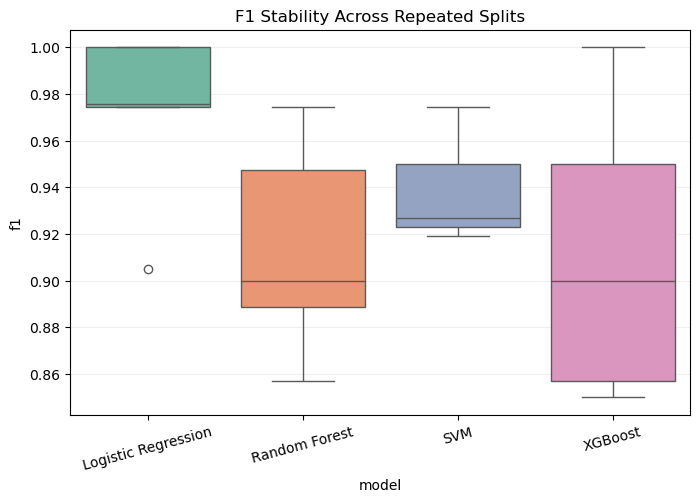

In [6]:
# Stability check across seeds (small repeated holdout on train set)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import clone

seed_models = {
    'Logistic Regression': trained_models['Logistic Regression'],
    'Random Forest': trained_models['Random Forest'],
    'SVM': trained_models['SVM'],
}
if 'XGBoost' in trained_models:
    seed_models['XGBoost'] = trained_models['XGBoost']

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
stability_rows = []

X_full = X_train.copy()
y_full = y_train.copy()

for split_id, (tr_idx, va_idx) in enumerate(sss.split(X_full, y_full), start=1):
    X_tr, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
    y_tr, y_va = y_full.iloc[tr_idx], y_full.iloc[va_idx]

    split_scaler = StandardScaler()
    X_tr_scaled = split_scaler.fit_transform(X_tr)
    X_va_scaled = split_scaler.transform(X_va)

    for model_name, model_template in seed_models.items():
        model = clone(model_template)

        if model_name in ['Logistic Regression', 'SVM']:
            model.fit(X_tr_scaled, y_tr)
            y_pred = model.predict(X_va_scaled)
        else:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_va)

        stability_rows.append({
            'split': split_id,
            'model': model_name,
            'f1': f1_score(y_va, y_pred, zero_division=0),
            'accuracy': accuracy_score(y_va, y_pred),
        })

stability_df = pd.DataFrame(stability_rows)
stability_summary = stability_df.groupby('model').agg(
    mean_f1=('f1', 'mean'),
    std_f1=('f1', 'std'),
    mean_acc=('accuracy', 'mean'),
    std_acc=('accuracy', 'std')
).reset_index().sort_values(by='mean_f1', ascending=False)

print('--- Stability Summary (5 splits) ---')
display(stability_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=stability_df, x='model', y='f1', palette='Set2')
plt.title('F1 Stability Across Repeated Splits')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.2)
plt.show()

### Stability, Reproducibility, and Deployment Readiness
To strengthen the final recommendation, we add a stability check across multiple random seeds. This helps verify that the selected model is not only strong on one split but also reliable under small sampling variations.

We also add a concise leakage-prevention checklist and practical deployment considerations, which are explicitly required in the final rubric narrative.

In [8]:
# Compact report summary (for direct copy into report text)
print('MODEL_COMPARISON')
display(comparison_df.round(4))

if 'stability_summary' in globals():
    print('STABILITY_SUMMARY')
    display(stability_summary.round(4))

print('LEAKAGE_CHECKLIST')
display(leakage_checklist)

MODEL_COMPARISON


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.92,1.0,0.800,0.8889,0.9983,0.9977
1,SVM,0.92,1.0,0.800,0.8889,0.9958,0.9942
2,Random Forest,0.90,1.0,0.750,0.8571,0.9771,0.9699
3,XGBoost,0.89,1.0,0.725,0.8406,0.9925,0.9905


STABILITY_SUMMARY


,model,mean_f1,std_f1,mean_acc,std_acc
0,Logistic Regression,0.9709,0.0391,0.976,0.0329
2,SVM,0.9386,0.0233,0.952,0.0179
1,Random Forest,0.9136,0.0469,0.932,0.0390
3,XGBoost,0.9114,0.0636,0.932,0.0482


LEAKAGE_CHECKLIST


,item,status
0,Scaler fit on train only,PASS
1,Hyperparameter tuning performed without test set,PASS
2,Feature engineering does not use target leakage,PASS
3,Model comparison uses same dev protocol across...,PASS
